In [2]:
import torch
import torch.nn as nn
import torchvision
from torchvision import models, transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import torch_directml

In [3]:
# Get computation device
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(torch.cuda.get_device_name(0))
elif torch_directml.is_available():
    device = torch_directml.device()
    print(torch_directml.device_name(0))
else:
    device = torch.device('cpu')
    print('cpu')

AMD Radeon(TM) Graphics 


In [4]:
# Get and process image
def get_image(path, transformer, size=(300, 300)):
    image = Image.open(path)
    image.resize(size, Image.Resampling.LANCZOS) # Interpolation type
    image = transformer(image)
    image = image.unsqueeze(0)
    return image.to(device)

In [5]:
# Get Gramm matrix
def get_gram(m):
    bs, c, h, w = m.size()
    m = m.view(c, h * w)
    m = torch.mm(m, m.t())
    return m

In [6]:
# Denormalization
def denormalize(image):
    image = image.permute(1, 2, 0)
    mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
    std = torch.tensor([0.229, 0.224, 0.225]).to(device)
    image = image * std + mean
    image = image.clamp(0, 1)
    return image.cpu().numpy()

In [7]:
# Model
class FeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.vgg = models.vgg16(pretrained=True).features
        self.selected_layers = [3, 8, 15, 22] # Layers after ReLU
    def forward(self, x):
        layer_features = []
        for layer_number, layer in enumerate(self.vgg):
            x = layer(x)
            if layer_number in self.selected_layers:
                layer_features.append(x)
        return layer_features

In [8]:
# Transformer
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406),
                         std=(0.229, 0.224, 0.225))
])

In [19]:
# Images
content_img = get_image("./source/NST/content.jpg", transformer, size=(300, 300))
style_img = get_image("./source/NST/style.jpg", transformer, size=(300, 300))
generated_img = content_img.clone().requires_grad_(True)

In [20]:
# Other variables
optimizer = torch.optim.Adam([generated_img],
                             lr=0.003,
                             betas=(0.5, 0.999))
encoder = FeatureExtractor().to(device)
for param in encoder.parameters():
    param.requires_grad_(False)

In [28]:
# Training
content_weight = 1
style_weight = 100
for epoch in range(1000):
    content_features = encoder(content_img)
    style_features = encoder(style_img)
    generated_features = encoder(generated_img)
    content_loss = torch.mean((content_features[-1] - generated_features[-1]) ** 2)
    style_loss = 0
    for gf, sf in zip(generated_features, style_features):
        bs, c, h, w = gf.size()
        gram_gf = get_gram(gf)
        gram_sf = get_gram(sf)
        style_loss += torch.mean((gram_gf - gram_sf) ** 2) / (c * h * w)
    loss = content_weight * content_loss + style_weight * style_loss
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch [{epoch}]")
        print(f"Content loss: {content_loss:.4f}")
        print(f"Style loss: {style_loss:.4f}")
        print()

Epoch [0]
Content loss: 3.2692
Style loss: 5.2254

Epoch [10]
Content loss: 3.2700
Style loss: 5.1976

Epoch [20]
Content loss: 3.2706
Style loss: 5.1701

Epoch [30]
Content loss: 3.2715
Style loss: 5.1428

Epoch [40]
Content loss: 3.2723
Style loss: 5.1157

Epoch [50]
Content loss: 3.2731
Style loss: 5.0888

Epoch [60]
Content loss: 3.2739
Style loss: 5.0622

Epoch [70]
Content loss: 3.2747
Style loss: 5.0356

Epoch [80]
Content loss: 3.2755
Style loss: 5.0092

Epoch [90]
Content loss: 3.2762
Style loss: 4.9830

Epoch [100]
Content loss: 3.2770
Style loss: 4.9570

Epoch [110]
Content loss: 3.2776
Style loss: 4.9312

Epoch [120]
Content loss: 3.2784
Style loss: 4.9055

Epoch [130]
Content loss: 3.2791
Style loss: 4.8801

Epoch [140]
Content loss: 3.2798
Style loss: 4.8548

Epoch [150]
Content loss: 3.2804
Style loss: 4.8297

Epoch [160]
Content loss: 3.2810
Style loss: 4.8049

Epoch [170]
Content loss: 3.2818
Style loss: 4.7802

Epoch [180]
Content loss: 3.2825
Style loss: 4.7556

Epoc

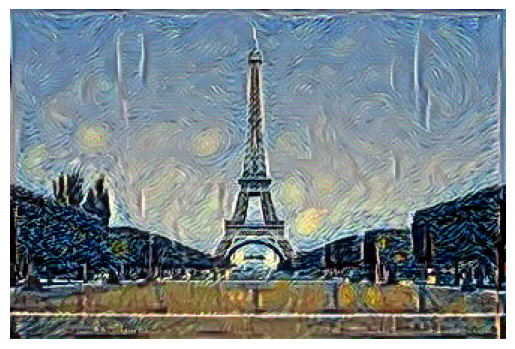

In [30]:
# Get image
output = generated_img.detach().squeeze(0)
output = denormalize(output)
plt.axis('off')
plt.imshow(output)